In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd

import matplotlib.pyplot as plt

from drawarrow import ax_arrow
from highlight_text import ax_text


## Load crop insurance data

I am using [state / county / crop summary of business](https://www.rma.usda.gov/tools-reports/summary-of-business/state-county-crop-summary-business) data from 1948 - 2026. 

### Crop insurance data from 1948 - 1988

The crop insurance data from this time period comes in a single text file.

In [2]:
CROP = 'soybeans'
PROJECT_ROOT = Path('.').resolve().parent
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_parquet(f'{INPUT_DIR}/usda_crop_insurance_1948_2026.parquet')
df = df.query(" commodity_name.str.contains(@CROP) ").reset_index(drop=True)

# unlike for cotton and corn, the crop insurance data for soybeans starts in 1955, not 1948
assert(df.commodity_year.min() == 1955 and df.commodity_year.max() == 2026)

df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
0,1955,IA,19033,CERRO GORDO,0081,soybeans,153,147,0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1955,IA,19081,HANCOCK,0081,soybeans,160,157,0,178.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1955,IA,19187,WEBSTER,0081,soybeans,151,150,0,181.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1955,IL,17117,MACOUPIN,0081,soybeans,161,147,0,179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1955,OH,39107,MERCER,0081,soybeans,194,182,0,206.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764262,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,02,RP,A,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
764263,2026,WV,54037,Jefferson,0081,soybeans,1,0,0,0.0,...,32,SCO-RP,A,RBUP,.7500,Acres,0.0,0.0,0.0,0.0
764264,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
764265,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0


In [3]:
# NOTE: we are only filtering the data since 1990 this for stats / figures purposes
df = df.query(" commodity_year >= 1990 ")
df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
30580,1990,AL,01003,Baldwin,0081,soybeans,8,0,0,0.0,...,90,APH,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
30581,1990,AL,01003,Baldwin,0081,soybeans,1,1,1,1.0,...,90,APH,E,RBUP,.5000,Acres,0.0,0.0,0.0,0.0
30582,1990,AL,01003,Baldwin,0081,soybeans,4,4,0,4.0,...,90,APH,E,FBUP,.5000,Acres,0.0,0.0,0.0,0.0
30583,1990,AL,01003,Baldwin,0081,soybeans,7,7,2,15.0,...,90,APH,E,FBUP,.6500,Acres,0.0,0.0,0.0,0.0
30584,1990,AL,01003,Baldwin,0081,soybeans,4,4,3,17.0,...,90,APH,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764262,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,02,RP,A,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
764263,2026,WV,54037,Jefferson,0081,soybeans,1,0,0,0.0,...,32,SCO-RP,A,RBUP,.7500,Acres,0.0,0.0,0.0,0.0
764264,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,01,YP,A,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
764265,2026,WV,54037,Jefferson,0081,soybeans,3,0,0,0.0,...,01,YP,A,RBUP,.7000,Acres,0.0,0.0,0.0,0.0


In [4]:
print('Commodity names:')
print(f'{df.commodity_name.values.unique().tolist()}')
print()

print('Commodity codes:')
print(f'{df.commodity_code.values.unique().tolist()}')
print()

print(f'States growing {CROP}:')
print(f'{sorted(df.state.values.unique().tolist())}')
print()

print('Insurance plans:')
print(f'{sorted(df.insurance_name.values.unique().fillna('').astype('str').tolist())}')
print()

print('Insurance codes:')
print(f'{sorted(df.insurance_code.values.unique().fillna('').astype('str').tolist())}')
print()


Commodity names:
['soybeans', 'grp soybeans', 'revenue coverage soybeans']

Commodity codes:
['0081', '0181', '0481']

States growing soybeans:
['AL', 'AR', 'CO', 'DE', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NJ', 'NY', 'OH', 'OK', 'OR', 'PA', 'SC', 'SD', 'TN', 'TX', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

Insurance plans:
['APH', 'ARP', 'ARP - HPE', 'AYP', 'CLIP', 'CRC', 'ECO-RP', 'ECO-RPHPE', 'ECO-YP', 'GRIP', 'GRIP-HRO', 'GRIPH', 'GRP', 'HIP-WI', 'IIP', 'IP', 'MCO-RP', 'MCO-RPHPE', 'MCO-YP', 'MP', 'MP-HPO', 'RA', 'RP', 'RPHPE', 'SCO-RP', 'SCO-RPHPE', 'SCO-YP', 'YP']

Insurance codes:
['01', '02', '03', '04', '05', '06', '12', '16', '17', '25', '31', '32', '33', '37', '42', '44', '45', '67', '68', '69', '73', '77', '87', '88', '89', '90']



The *grp soybeans* and *income protection soybeans* values are in the `commodity_name` column are insurance plans. In our case, there are several thousand rows of these policies, but still  make up less than 1% of our dataset.


In [5]:
only_insurance = df.query(" commodity_code != '0081' ")
assert(only_insurance.endorsed_acres.all() == 0)
only_insurance


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
43482,1993,AR,05077,Lee,0181,grp soybeans,5,5,0,5.0,...,12,GRP,E,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
43496,1993,AR,05085,Lonoke,0181,grp soybeans,6,6,0,6.0,...,12,GRP,E,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
43497,1993,AR,05085,Lonoke,0181,grp soybeans,1,1,0,1.0,...,12,GRP,E,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
43520,1993,AR,05111,Poinsett,0181,grp soybeans,2,2,2,2.0,...,12,GRP,E,RBUP,.8000,Acres,0.0,0.0,0.0,0.0
43521,1993,AR,05111,Poinsett,0181,grp soybeans,2,2,2,2.0,...,12,GRP,E,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81421,1996,WI,55059,Kenosha,0181,grp soybeans,2,2,2,2.0,...,12,GRP,L,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
81558,1996,WI,55101,Racine,0181,grp soybeans,3,0,0,0.0,...,12,GRP,L,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
81559,1996,WI,55101,Racine,0181,grp soybeans,16,16,16,16.0,...,12,GRP,L,RBUP,.7000,Acres,0.0,0.0,0.0,0.0
81560,1996,WI,55101,Racine,0181,grp soybeans,1,1,1,1.0,...,12,GRP,L,RBUP,.7500,Acres,0.0,0.0,0.0,0.0


## Load in state and county boundaries from Natural Earth

In [6]:
world_states_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces_lakes.zip'
world_states = gpd.read_file(world_states_url)
states = world_states.query(" adm0_a3 == 'USA' ")
states = states[['name', 'postal', 'geometry']]
states.columns = ['name', 'state', 'geometry']
states = states.query(" state != 'AK' and state != 'DC' and state != 'HI' ")
states = states.sort_values(by='state').reset_index(drop=True)
states


,name,state,geometry
0,Alabama,AL,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
1,Arkansas,AR,"POLYGON ((-90.30422 35.00008, -90.30124 34.995..."
2,Arizona,AZ,"POLYGON ((-111.00627 31.32718, -111.06712 31.3..."
3,California,CA,"MULTIPOLYGON (((-114.72428 32.71284, -114.7645..."
4,Colorado,CO,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
5,Connecticut,CT,"POLYGON ((-73.6417 41.00177, -73.64286 41.0010..."
6,Delaware,DE,"POLYGON ((-75.05809 38.45372, -75.06273 38.457..."
7,Florida,FL,"MULTIPOLYGON (((-87.44734 30.31314, -87.46443 ..."
8,Georgia,GA,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
9,Iowa,IA,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."


In [7]:
counties_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties_lakes.zip'
counties = gpd.read_file(counties_url)

counties = counties[['NAME', 'NAME_ALT', 'REGION', 'FIPS', 'geometry']]
counties.columns = ['name', 'name_alt', 'region', 'fips', 'geometry']

# remove the 'US' value prepended to the fips codes
counties['fips'] = [fips[2:] for fips in counties.fips]

# we want to exclude alaska, d.c., hawaii, puerto rico, and the usa virgin islands here
counties = counties.query(" region != 'AK' and region != 'DC' and region != 'HI' and region != 'PR' and region != 'VI' ")
counties.rename(columns={'region':'state'}, inplace=True)
counties


,name,name_alt,state,fips,geometry
0,Whatcom,Whatcom County,WA,53073,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
1,Okanogan,Okanogan County,WA,53047,"POLYGON ((-120.85196 48.99251, -120.67495 48.9..."
2,Ferry,Ferry County,WA,53019,"POLYGON ((-118.83688 48.99251, -118.69668 48.9..."
3,Stevens,Stevens County,WA,53065,"POLYGON ((-118.21996 48.99251, -118.03723 48.9..."
4,Pend Oreille,Pend Oreille County,WA,53051,"POLYGON ((-117.42951 48.99251, -117.37787 48.9..."
...,...,...,...,...,...
3185,Washakie,Washakie County,WY,56043,"POLYGON ((-108.55055 44.16845, -108.19008 44.1..."
3186,Fremont,Fremont County,WY,56013,"POLYGON ((-107.52291 42.43435, -107.52271 42.2..."
3187,Natrona,Natrona County,WY,56025,"POLYGON ((-106.07584 42.43321, -106.32218 42.4..."
3188,Hot Springs,Hot Springs County,WY,56017,"POLYGON ((-107.59509 43.50139, -107.59512 43.4..."


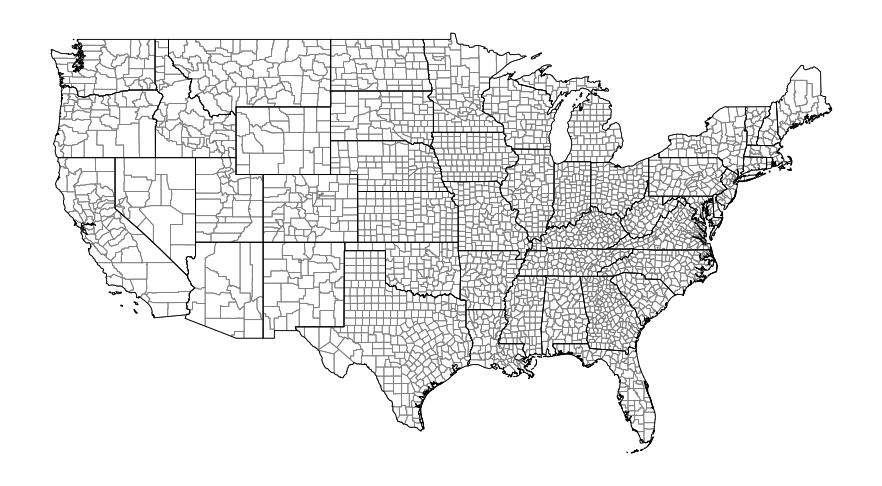

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

counties.plot(facecolor='none', edgecolor='gray', linewidth=0.5, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

ax.axis('off')

plt.show()


## Analyzing premiums and subsidies

In [9]:
premiums_subsidies_indemnities = df[['commodity_year', 'total_premium', 'subsidy', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
premiums_subsidies_indemnities.head()


,commodity_year,total_premium,subsidy,indemnity
0,1990,102205403.0,25359868.0,79774022.0
1,1991,83499952.0,21148851.0,82946460.0
2,1992,91889041.0,23437213.0,55373867.0
3,1993,89883790.0,23233880.0,226678759.0
4,1994,128221882.0,33948590.0,44118743.0


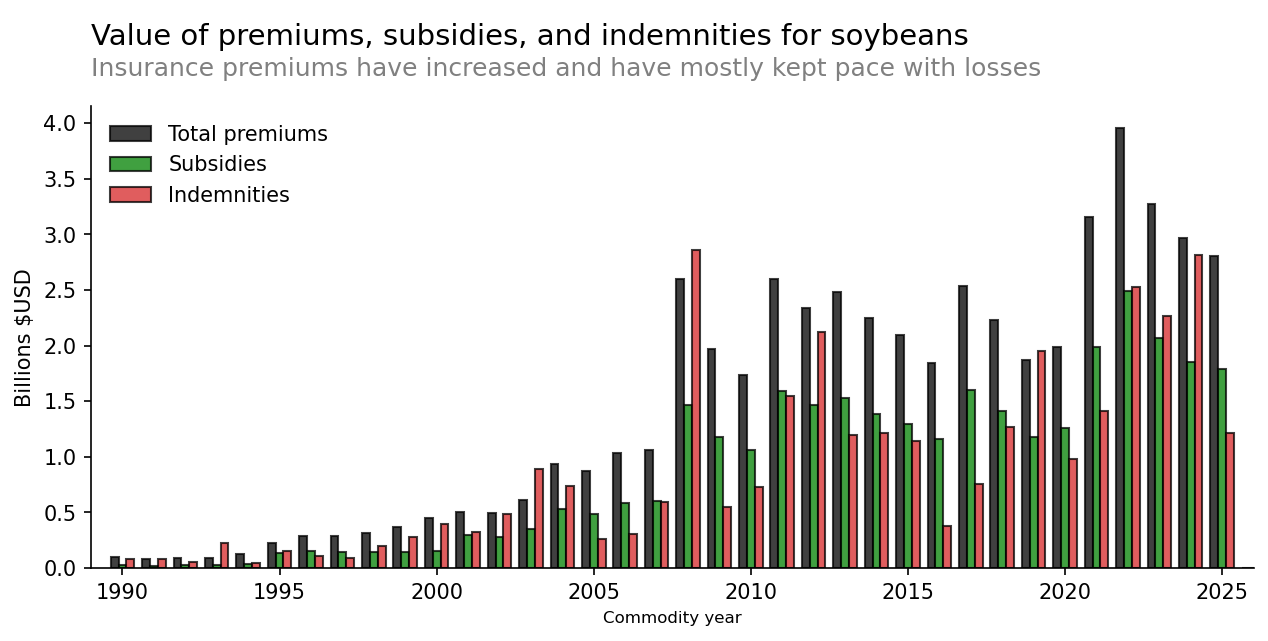

In [10]:
width = 0.25
multiplier = -1
x = premiums_subsidies_indemnities.commodity_year.values

arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

for col, values in premiums_subsidies_indemnities.drop('commodity_year', axis=1).items():

    if col == 'total_premium':
        color = 'black'
        label = 'Total premiums'
    elif col == 'subsidy':
        color = 'green'
        label = 'Subsidies'
    else:
        color = 'tab:red'
        label = 'Indemnities'
    
    offset = width * multiplier
    
    rects = ax.bar(
        x + offset, values, 
        width, 
        color=color,
        edgecolor='black', 
        alpha=0.75,
        label=label,
    )
    
    multiplier += 1

ax.set_xlabel('Commodity year', size=8)

ax.set_xlim([1989, 2026])
ax.set_yticks(ticks=np.arange(0, 4.5e9, 0.5e9), labels=np.arange(0, 4.5, 0.5))
ax.set_ylabel('Billions $USD')

ax.legend(loc='upper left', frameon=False)

s = f'Value of premiums, subsidies, and indemnities for {CROP}'
ax_text(x=1989, y=4.9e9, s=s, size=14, ha='left')

s = 'Insurance premiums have increased and have mostly kept pace with losses'
ax_text(x=1989, y=4.6e9, s=s, size=12, color='gray', ha='left')

ax.spines[['top', 'right']].set_visible(False)

plt.show()


## Indemnities

### By time

In [11]:
val_indemnities_by_year = df[['commodity_year', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
val_indemnities_by_year


,commodity_year,indemnity
0,1990,7.977402e+07
1,1991,8.294646e+07
2,1992,5.537387e+07
3,1993,2.266788e+08
4,1994,4.411874e+07
5,1995,1.550388e+08
6,1996,1.085201e+08
7,1997,9.508445e+07
8,1998,1.973846e+08
9,1999,2.834502e+08


In [12]:
val_indemnities_by_state_and_year = df[['state', 'commodity_year', 'indemnity']].groupby(by=['state', 'commodity_year']).sum()
val_indemnities_by_state_and_year = val_indemnities_by_state_and_year.reset_index()
val_indemnities_by_state_and_year


,state,commodity_year,indemnity
0,AL,1990,1979820.0
1,AL,1991,226633.0
2,AL,1992,157581.0
3,AL,1993,126749.0
4,AL,1994,53568.0
...,...,...,...
1222,WV,2024,1217048.0
1223,WV,2025,548268.0
1224,WV,2026,0.0
1225,WY,2018,8923.0


### By state

In [13]:
num_indemnities_by_state = df[['state', 'policies_indemnified']].groupby(by='state').sum()
num_indemnities_by_state = num_indemnities_by_state.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_state = num_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'policies_indemnified', 'geometry']]
num_indemnities_by_state = gpd.GeoDataFrame(num_indemnities_by_state).set_geometry('geometry')
num_indemnities_by_state = num_indemnities_by_state.query(" policies_indemnified > 0 ")
num_indemnities_by_state


,state,name,policies_indemnified,geometry
0,IA,Iowa,372609,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."
1,IL,Illinois,329199,"POLYGON ((-89.1237 36.97964, -89.14345 36.9868..."
2,MN,Minnesota,270472,"POLYGON ((-97.22609 48.99267, -97.15538 48.992..."
3,KS,Kansas,248281,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
4,NE,Nebraska,245785,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
5,MO,Missouri,224599,"POLYGON ((-95.31725 40.0001, -95.34421 40.0192..."
6,SD,South Dakota,210334,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
7,IN,Indiana,162805,"POLYGON ((-84.80608 41.69681, -84.80608 41.617..."
8,OH,Ohio,161550,"POLYGON ((-80.52023 41.98446, -80.52023 41.904..."
9,ND,North Dakota,143459,"POLYGON ((-104.04757 48.99262, -103.96949 48.9..."


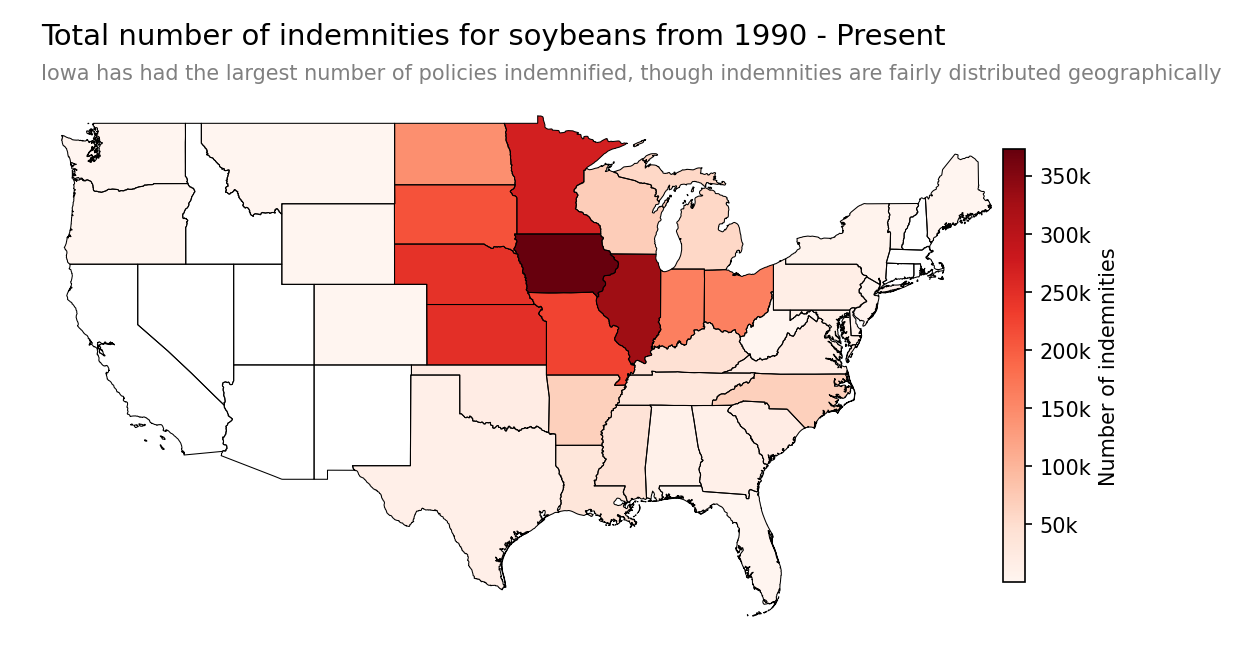

In [14]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_state.plot(column='policies_indemnified', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_state['policies_indemnified'].min()
vmax = num_indemnities_by_state['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(50000, 400000, 50000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(50, 400, 50)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = 'Iowa has had the largest number of policies indemnified, though indemnities are fairly distributed geographically'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')
ax.axis('off')

plt.show()


In [15]:
val_indemnities_by_state = df[['state', 'indemnity']].groupby(by='state').sum()
val_indemnities_by_state = val_indemnities_by_state.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_state = val_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'indemnity', 'geometry']]
val_indemnities_by_state = gpd.GeoDataFrame(val_indemnities_by_state).set_geometry('geometry')
val_indemnities_by_state = val_indemnities_by_state.query(" indemnity > 0 ")
val_indemnities_by_state


,state,name,indemnity,geometry
0,MN,Minnesota,3.207694e+09,"POLYGON ((-97.22609 48.99267, -97.15538 48.992..."
1,ND,North Dakota,3.117101e+09,"POLYGON ((-104.04757 48.99262, -103.96949 48.9..."
2,IA,Iowa,3.024333e+09,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."
3,SD,South Dakota,2.859107e+09,"POLYGON ((-104.05666 45.0001, -104.0393 44.999..."
4,MO,Missouri,2.510191e+09,"POLYGON ((-95.31725 40.0001, -95.34421 40.0192..."
5,KS,Kansas,2.423921e+09,"POLYGON ((-102.03957 36.99981, -102.03994 37.0..."
6,IL,Illinois,2.148972e+09,"POLYGON ((-89.1237 36.97964, -89.14345 36.9868..."
7,NE,Nebraska,2.110845e+09,"POLYGON ((-104.05373 40.99983, -104.05292 41.1..."
8,IN,Indiana,1.590482e+09,"POLYGON ((-84.80608 41.69681, -84.80608 41.617..."
9,OH,Ohio,1.481810e+09,"POLYGON ((-80.52023 41.98446, -80.52023 41.904..."


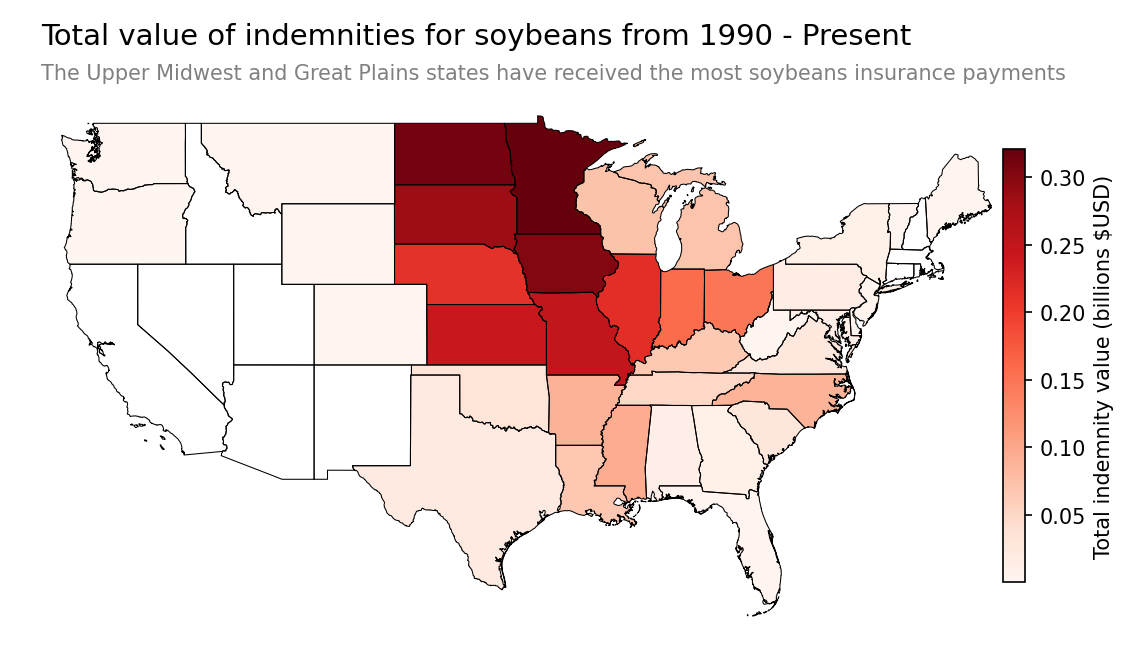

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_state.plot(column='indemnity', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_state['indemnity'].min()
vmax = val_indemnities_by_state['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.05e10, 0.35e10, 0.05e10))
cbar.set_ticklabels([f'{val:.2f}' for val in np.arange(0.05, 0.35, 0.05)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'The Upper Midwest and Great Plains states have received the most {CROP} insurance payments'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


### By county

In [17]:
num_indemnities_by_county = df[['fips', 'county_name', 'policies_indemnified']].groupby(by=['fips', 'county_name']).sum()
num_indemnities_by_county = num_indemnities_by_county.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_county = num_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'policies_indemnified', 'geometry']]
num_indemnities_by_county = gpd.GeoDataFrame(num_indemnities_by_county).set_geometry('geometry')
num_indemnities_by_county = num_indemnities_by_county.query(" policies_indemnified > 0 ")
num_indemnities_by_county


,state,name,fips,policies_indemnified,geometry
0,IL,Iroquois,17075,14865,"POLYGON ((-87.52589 40.73694, -87.52604 40.703..."
1,IL,Livingston,17105,13430,"POLYGON ((-88.24718 40.99474, -88.24157 40.824..."
2,SD,Brown,46013,11500,"POLYGON ((-98.00811 45.94185, -97.97877 45.941..."
3,SD,Hutchinson,46067,10962,"POLYGON ((-97.63749 43.16876, -98.0771 43.1683..."
4,MN,Redwood,27127,9850,"POLYGON ((-94.86962 44.50373, -94.86625 44.282..."
...,...,...,...,...,...
1858,OK,Murray,40099,1,"POLYGON ((-96.93345 34.33265, -97.0287 34.3326..."
1859,VA,Middlesex,51119,1,"POLYGON ((-76.6752 37.76822, -76.66866 37.7555..."
1860,VA,Botetourt,51023,1,"POLYGON ((-79.674 37.76304, -79.68872 37.73466..."
1861,IL,DuPage,17043,1,"POLYGON ((-88.26287 41.98622, -88.14703 41.988..."


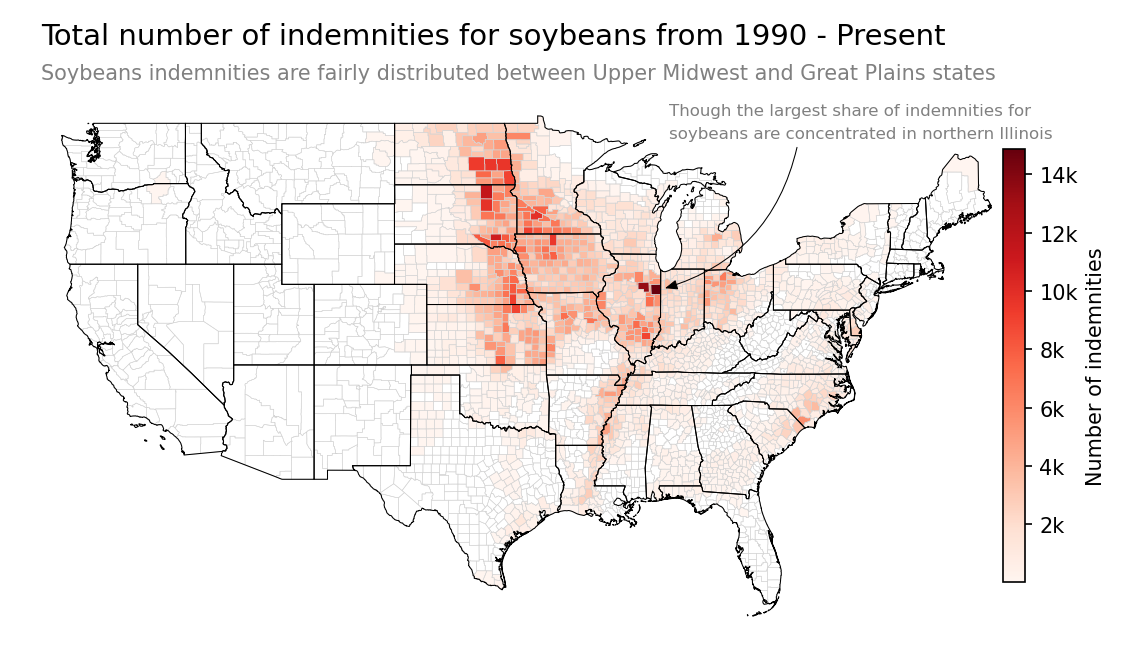

In [18]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_county.plot(column='policies_indemnified', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_county['policies_indemnified'].min()
vmax = num_indemnities_by_county['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(2000, 16000, 2000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(2, 16, 2)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'{CROP.title()} indemnities are fairly distributed between Upper Midwest and Great Plains states'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

s = f'Though the largest share of indemnities for\n{CROP} are concentrated in northern Illinois'
ax_text(x=-87, y=50, s=s, size=8, color='gray', ha='left')
ax_arrow(tail_position=(-79, 48), head_position=(-87.5, 40.75), radius=0.3, invert=True, **arrow_props)

ax.axis('off')

plt.show()


In [19]:
val_indemnities_by_county = df[['fips', 'county_name', 'indemnity']].groupby(by=['fips', 'county_name']).sum()
val_indemnities_by_county = val_indemnities_by_county.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_county = val_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'indemnity', 'geometry']]
val_indemnities_by_county = gpd.GeoDataFrame(val_indemnities_by_county).set_geometry('geometry')
val_indemnities_by_county = val_indemnities_by_county.query(" indemnity > 0 ")
val_indemnities_by_county


,state,name,fips,indemnity,geometry
0,ND,Stutsman,38093,261630199.0,"POLYGON ((-98.46747 47.24045, -98.46752 46.979..."
1,SD,Brown,46013,250145627.0,"POLYGON ((-98.00811 45.94185, -97.97877 45.941..."
2,ND,Barnes,38003,214943388.0,"POLYGON ((-97.96118 47.24051, -97.70603 47.239..."
3,ND,Cass,38017,214553613.0,"POLYGON ((-96.8332 47.15061, -96.83591 47.1406..."
4,ND,LaMoure,38045,182369978.0,"POLYGON ((-98.43905 46.63111, -98.03385 46.630..."
...,...,...,...,...,...
1858,OK,Greer,40055,263.0,"POLYGON ((-99.88856 35.03026, -99.78294 35.030..."
1859,AL,Fayette,01057,232.0,"POLYGON ((-87.63593 33.91524, -87.63605 33.871..."
1860,OK,Johnston,40069,125.0,"POLYGON ((-96.40733 34.41853, -96.40763 34.157..."
1861,TN,Lewis,47101,92.0,"POLYGON ((-87.65818 35.60934, -87.63499 35.614..."


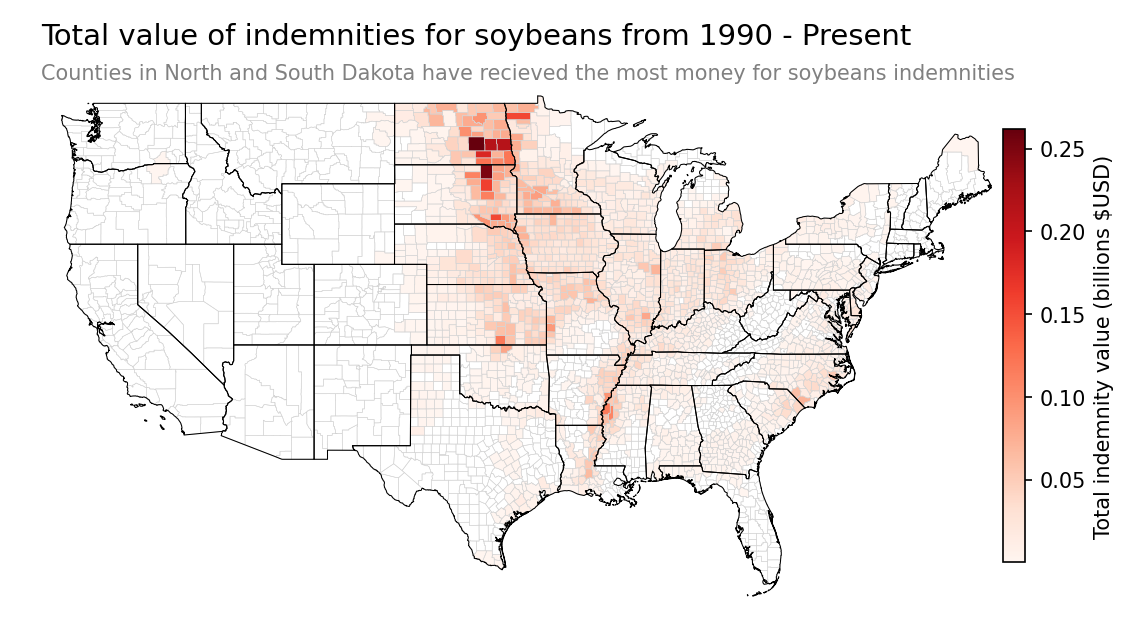

In [20]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_county.plot(column='indemnity', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_county['indemnity'].min()
vmax = val_indemnities_by_county['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.05e9, 0.30e9, 0.05e9))
cbar.set_ticklabels([f'{val:.2f}' for val in np.arange(0.05, 0.3, 0.05)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=53, s=s, size=14, color='black', ha='left')

s = f'Counties in North and South Dakota have recieved the most money for {CROP} indemnities'
ax_text(x=-126, y=51, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


In [21]:
loss_ratio_by_county = df[['fips', 'county_name', 'loss_ratio']].groupby(by=['fips', 'county_name']).mean()
loss_ratio_by_county = loss_ratio_by_county.sort_values(by='loss_ratio', ascending=False).reset_index()
loss_ratio_by_county = loss_ratio_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'loss_ratio', 'geometry']]
loss_ratio_by_county = gpd.GeoDataFrame(loss_ratio_by_county).set_geometry('geometry')
loss_ratio_by_county = loss_ratio_by_county.query(" loss_ratio > 0 ")
loss_ratio_by_county


,state,name,fips,loss_ratio,geometry
0,SD,Jackson,46071,5.177500,"POLYGON ((-101.22817 43.38918, -101.62542 43.3..."
1,TX,Limestone,48293,3.070000,"POLYGON ((-96.59685 31.22089, -96.70059 31.374..."
2,TN,Meigs,47121,2.960000,"POLYGON ((-84.85078 35.35993, -84.87324 35.348..."
3,TX,Navarro,48349,2.951667,"POLYGON ((-96.8962 32.07397, -96.74986 32.1464..."
4,SC,Cherokee,45021,2.816000,"POLYGON ((-81.87425 35.18826, -81.85312 35.187..."
...,...,...,...,...,...
1857,TX,Gray,48179,0.038388,"POLYGON ((-101.08627 35.18213, -101.086 35.375..."
1858,VA,Middlesex,51119,0.026364,"POLYGON ((-76.6752 37.76822, -76.66866 37.7555..."
1859,TX,Fayette,48149,0.018415,"POLYGON ((-96.62197 30.04427, -96.56984 29.961..."
1860,AL,Fayette,01057,0.018333,"POLYGON ((-87.63593 33.91524, -87.63605 33.871..."


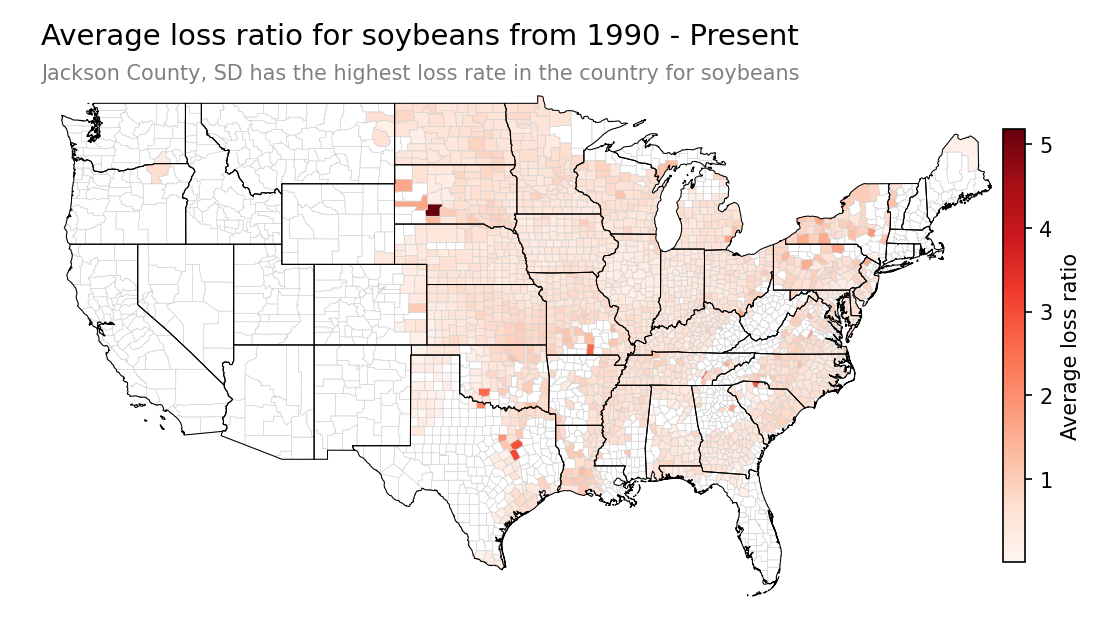

In [22]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

loss_ratio_by_county.plot(column='loss_ratio', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = loss_ratio_by_county['loss_ratio'].min()
vmax = loss_ratio_by_county['loss_ratio'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_label('Average loss ratio')

s = f'Average loss ratio for {CROP} from 1990 - Present'
ax_text(x=-126, y=53, s=s, size=14, color='black', ha='left')

s = f'{loss_ratio_by_county.iloc[0]['name']} County, {loss_ratio_by_county.iloc[0]['state']} has the highest loss rate in the country for {CROP}'
ax_text(x=-126, y=51, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()
